Prediction of Parkinson’s Disease Motor Severity

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Load the Dataset and the first five rows are displayed to understand the structure of the dataset.

In [ ]:
df = pd.read_csv("../data/parkinsons_updrs.csv")
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


 Check Dataset Size

The shape of the dataset tells us the total number of observations and variables.

- Rows represent individual observations.
- Columns represent different features and target variables.

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5875
Number of columns: 22


View Column Names

The column names are displayed to identify the available input features and possible target variables.

In [11]:
df.columns

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

 Dataset Information

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

Statistical Summary

In [13]:
df.describe()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


Check Missing Values

In [14]:
df.isnull().sum()

subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

Check Duplicate Rows

Duplicate observations may unnecessarily repeat the same information.

Therefore, the dataset is checked for duplicate rows.

In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Remove Duplicate Rows

Any exact duplicate observations are removed from the dataset to avoid repeated records during model training.

In [16]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5875, 22)


Distribution of Target Variable

The target variable selected for this regression problem is "total_UPDRS".

A histogram is plotted to understand how the target values are distributed.

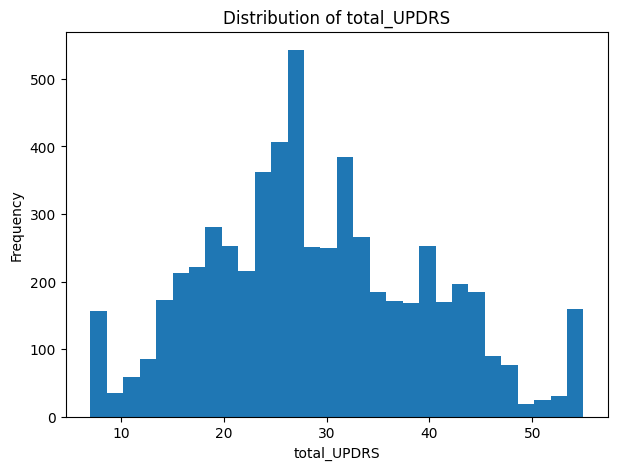

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(df["total_UPDRS"], bins=30)
plt.xlabel("total_UPDRS")
plt.ylabel("Frequency")
plt.title("Distribution of total_UPDRS")
plt.show()

 Distribution of Age

The distribution of the age feature is examined to understand the age range of the patients present in the dataset.

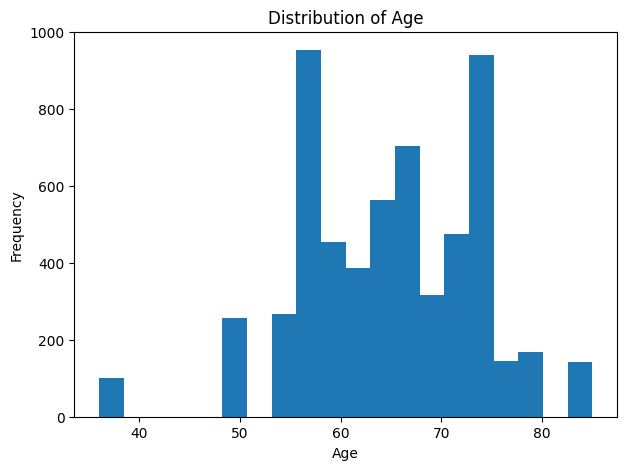

In [18]:
plt.figure(figsize=(7, 5))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

 Distribution of PPE

PPE is one of the voice-related features available in the dataset.

Its distribution is examined to understand the range and frequency of PPE values.

Voice features such as PPE can contain useful information about Parkinson's disease severity.

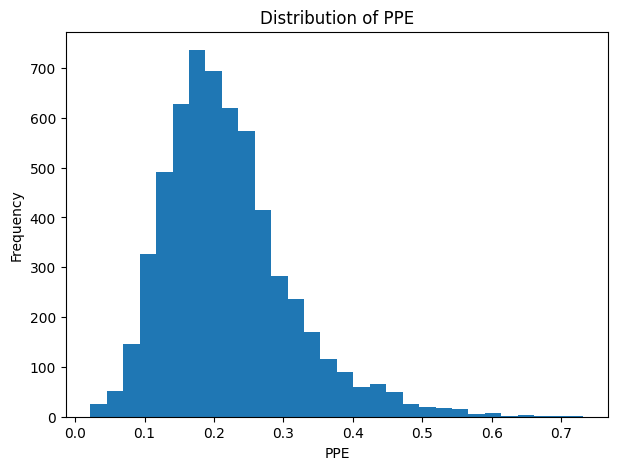

In [19]:
plt.figure(figsize=(7, 5))
plt.hist(df["PPE"], bins=30)
plt.xlabel("PPE")
plt.ylabel("Frequency")
plt.title("Distribution of PPE")
plt.show()

Correlation Heatmap

The correlation heatmap shows positive and negative relationships between the numerical variables.

Features showing stronger correlation with 'total_UPDRS' may be useful predictors for the regression models.

The heatmap also helps identify highly correlated input variables.

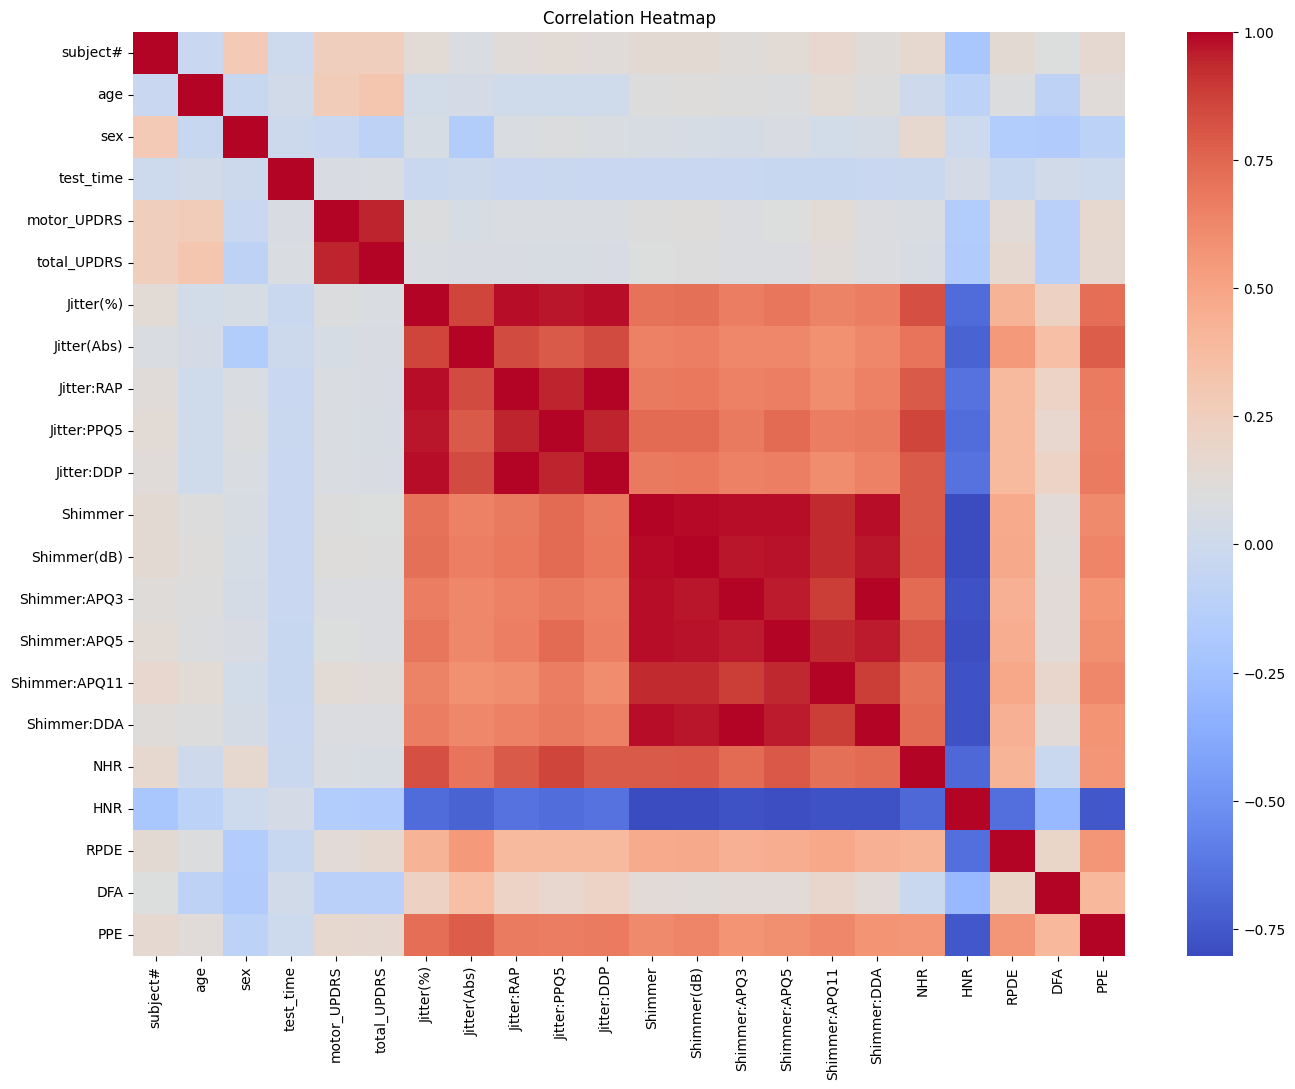

In [20]:
plt.figure(figsize=(16, 12))
correlation = df.corr()
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Correlation of Features with total_UPDRS
The correlation values help identify which variables have stronger linear relationships with 'total_UPDRS'.

A larger positive or negative correlation indicates a stronger relationship with the target variable.

In [21]:
correlation["total_UPDRS"].sort_values(ascending=False)

total_UPDRS      1.000000
motor_UPDRS      0.947231
age              0.310290
subject#         0.253643
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Shimmer:APQ3     0.079363
test_time        0.075263
Jitter(%)        0.074247
Jitter(Abs)      0.066927
Jitter:DDP       0.064027
Jitter:RAP       0.064015
Jitter:PPQ5      0.063352
NHR              0.060952
sex             -0.096559
DFA             -0.113475
HNR             -0.162117
Name: total_UPDRS, dtype: float64

Relationship Between Age and total_UPDRS

A scatter plot is used to study the relationship between the patient's age and total_UPDRS

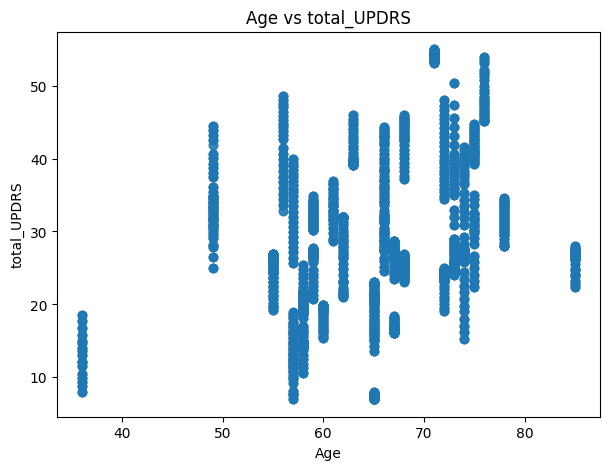

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(df["age"], df["total_UPDRS"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("total_UPDRS")
plt.title("Age vs total_UPDRS")
plt.show()

Relationship Between PPE and total_UPDRS

The scatter plot shows the relationship between PPE and 'total_UPDRS'.

The distribution of points indicates that voice measurements can provide useful information for predicting Park

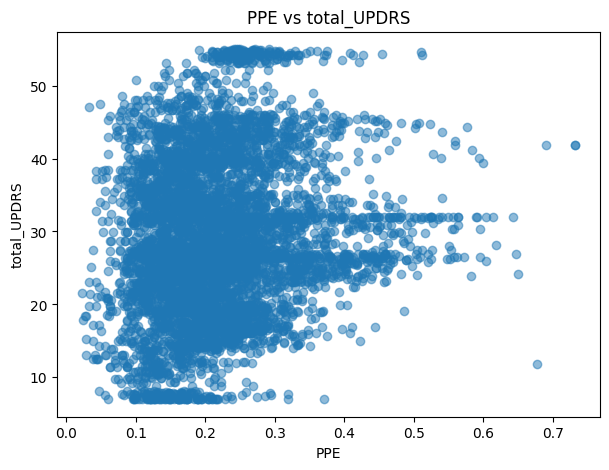

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(df["PPE"], df["total_UPDRS"], alpha=0.5)
plt.xlabel("PPE")
plt.ylabel("total_UPDRS")
plt.title("PPE vs total_UPDRS")
plt.show()

 Handle Missing Values
 

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

Feature Engineering

A new feature called 'Shimmer_Jitter_Ratio' is created.

Jitter represents variations in voice frequency, while Shimmer represents variations in voice amplitude.

Combining them provides an additional measure of voice instability that may help the machine learning models

In [25]:
df["Shimmer_Jitter_Ratio"] = (
    df["Shimmer"] / (df["Jitter(%)"] + 0.000001))
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,Shimmer_Jitter_Ratio
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,3.874037
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,6.744419
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,3.481605
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,4.372278
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,5.082065


### Observation
The target has a broad continuous range rather than separate classes, supporting the regression formulation.

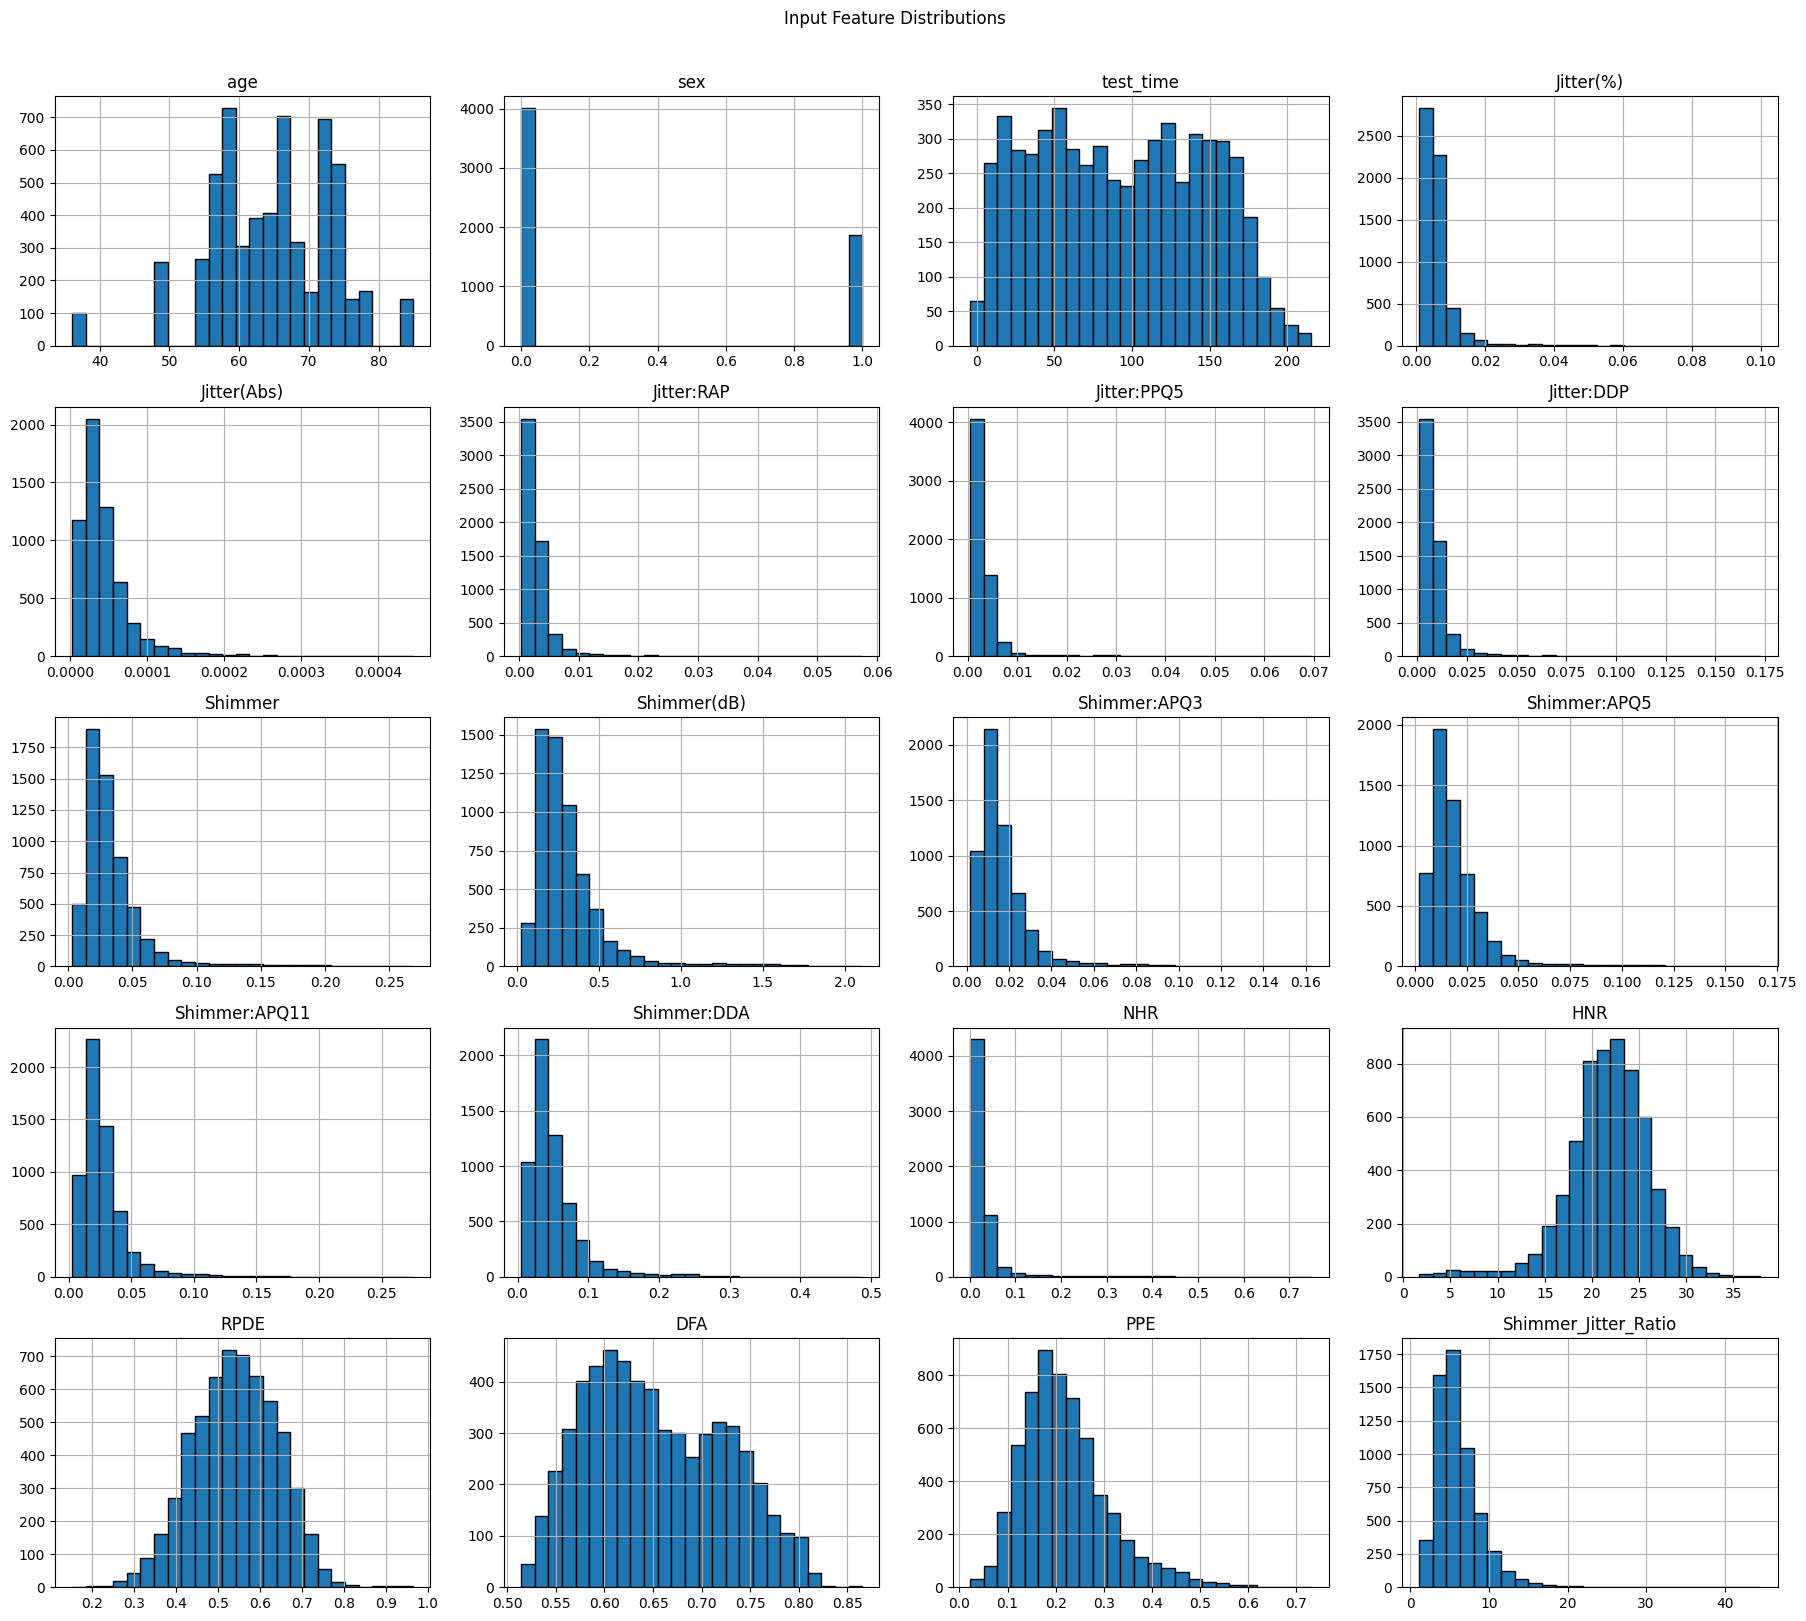

In [26]:
features=[c for c in df.columns if c not in ["subject#","motor_UPDRS","total_UPDRS"]]
df[features].hist(figsize=(18,16),bins=25,edgecolor="black")
plt.suptitle("Input Feature Distributions",y=1.01); plt.tight_layout(); plt.show()

Defining Input Feature and Target Variable

Data set is separated into

X - Input feature
Y - Target variable -> 'total_UPDRS'

'subject' is removed because it is only an identification number.

'motor_UPDRS' is also removed because it is another clinical UPDRS score that is closely related to the target variable.

In [27]:
X = df.drop(
    columns=[
        "subject#",
        "motor_UPDRS",
        "total_UPDRS"
    ]
)
y = df["total_UPDRS"]

Check Input and Target Dimensions

The dimensions of the input features and target variable are checked before splitting the dataset

In [28]:
print("Input shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Input shape: (5875, 20)
Target shape: (5875,)


,age,sex,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,Shimmer_Jitter_Ratio
0,72,0,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,3.874037
1,72,0,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,6.744419
2,72,0,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,3.481605
3,72,0,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,4.372278
4,72,0,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,5.082065


Train-Test Split

The dataset is divided into:

- **80% training data**
- **20% testing data**

Training data is used to train the machine learning models.

Testing data is kept separate and is used to evaluate how well the trained models perform on unseen data.

'random_state=42' is used to make the result reproducible.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4700, 20)
Testing data: (1175, 20)


 Feature Scaling

Some regression algorithms are sensitive to the scale of the input variables.

StandardScaler transforms the features so that they have approximately:

- Mean = 0
- Standard deviation = 1

The scaler is fitted only on the training data to avoid data leakage.

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regression Model Training

Ten regression algorithms are implemented and compared.

The models are:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor
10. K-Nearest Neighbors Regressor

The models are evaluated using:

- R² Score
- RMSE
- MAE

### 1.Linear Regression 

The model is evaluated using R², RMSE and MAE.

In [31]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)
print("R2:", linear_r2)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)

R2: 0.15866425588460387
RMSE: 9.65561879219046
MAE: 8.04149591411084


## 2.Ridge Regression
Ridge Regression is a regularized linear regression technique.

It uses L2 regularization to reduce overfitting by penalizing very large model coefficients.

In [32]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)
print("R2:", ridge_r2)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)

R2: 0.1585277601336159
RMSE: 9.65640200953072
MAE: 8.042366093195332


## 3.Lasso Regression

Lasso Regression uses L1 regularization.

It can reduce some coefficients to zero and therefore may also perform feature selection.

In [33]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)
lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)
print("R2:", lasso_r2)
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)

R2: 0.1599659831638931
RMSE: 9.648146241569394
MAE: 8.043771576877372


## 4.ElasticNet Regression

ElasticNet combines both L1 and L2 regularization.

Therefore, it combines characteristics of both Lasso and Ridge Regression.

In [34]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)
elastic_model.fit(
    X_train_scaled,
    y_train
)
elastic_pred = elastic_model.predict(
    X_test_scaled
)
elastic_r2 = r2_score(
    y_test,
    elastic_pred
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        elastic_pred
    )
)
elastic_mae = mean_absolute_error(
    y_test,
    elastic_pred
)
print("R2:", elastic_r2)
print("RMSE:", elastic_rmse)
print("MAE:", elastic_mae)

R2: 0.1605891870401015
RMSE: 9.644566697398988
MAE: 8.04147884841466


## 5.Polynomial Regression

Polynomial Regression allows the model to learn nonlinear relationships between the input features and the target.

Polynomial features of degree 2 are created.

In [35]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)
X_train_poly = poly.fit_transform(
    X_train_scaled
)
X_test_poly = poly.transform(
    X_test_scaled
)
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)
poly_pred = poly_model.predict(
    X_test_poly
)
poly_r2 = r2_score(
    y_test,
    poly_pred
)
poly_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        poly_pred
    )
)
poly_mae = mean_absolute_error(
    y_test,
    poly_pred
)
print("R2:", poly_r2)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)

R2: -0.7850546526493609
RMSE: 14.064399686949006
MAE: 7.591197225370982


## 6. Decision Tree Regressor

Decision Tree Regression divides the feature space into different regions and predicts values based on decision rules.

A maximum tree depth of 10 is used to control model complexity.

In [36]:
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)
tree_model.fit(
    X_train,
    y_train
)
tree_pred = tree_model.predict(
    X_test
)
tree_r2 = r2_score(
    y_test,
    tree_pred
)
tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_pred
    )
)
tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)
print("R2:", tree_r2)
print("RMSE:", tree_rmse)
print("MAE:", tree_mae)

R2: 0.9163248395514789
RMSE: 3.0450450209590105
MAE: 1.3087528235507166


## 7.Random Forest Regressor

Random Forest is an ensemble learning technique that combines predictions from many decision trees.

Using multiple trees generally improves prediction accuracy and reduces overfitting compared with a single decision tree.

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)
rf_pred = rf_model.predict(
    X_test
)
rf_r2 = r2_score(
    y_test,
    rf_pred
)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)
print("R2:", rf_r2)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)

R2: 0.9764098296490737
RMSE: 1.6168174198236405
MAE: 0.7384765259574458


## 8.Gradient Boosting Regressor

Gradient Boosting builds multiple weak learners sequentially.

Each new model attempts to correct the errors made by the previous models.

In [38]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    random_state=42
)
gb_model.fit(
    X_train,
    y_train
)
gb_pred = gb_model.predict(
    X_test
)
gb_r2 = r2_score(
    y_test,
    gb_pred
)
gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)
print("R2:", gb_r2)
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)

R2: 0.7768686125749086
RMSE: 4.97251124694501
MAE: 3.905941815368208


## 9.Support Vector Regression

Support Vector Regression attempts to find a function that predicts the target values while keeping prediction errors within an acceptable margin.

The RBF kernel is used to learn nonlinear relationships.

In [39]:
from sklearn.svm import SVR
svr_model = SVR(
    kernel="rbf",
    C=10
)
svr_model.fit(
    X_train_scaled,
    y_train
)
svr_pred = svr_model.predict(
    X_test_scaled
)
svr_r2 = r2_score(
    y_test,
    svr_pred
)
svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        svr_pred
    )
)
svr_mae = mean_absolute_error(
    y_test,
    svr_pred
)
print("R2:", svr_r2)
print("RMSE:", svr_rmse)
print("MAE:", svr_mae)

R2: 0.47233830427639134
RMSE: 7.646685448415717
MAE: 5.608706643735277


## 10. K-Nearest Neighbors Regressor

KNN Regression predicts the target value using the target values of nearby observations.

Here, the five nearest neighbours are considered.

In [40]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(
    n_neighbors=5
)
knn_model.fit(
    X_train_scaled,
    y_train
)
knn_pred = knn_model.predict(
    X_test_scaled
)
knn_r2 = r2_score(
    y_test,
    knn_pred
)

knn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        knn_pred
    )
)
knn_mae = mean_absolute_error(
    y_test,
    knn_pred
)
print("R2:", knn_r2)
print("RMSE:", knn_rmse)
print("MAE:", knn_mae)

R2: 0.6375054733699723
RMSE: 6.337911460650995
MAE: 4.0604108765957445


# Comparison of Regression Models

All ten models are now compared using the same test dataset.

The following metrics are considered:

### R² Score
R² measures how much variation in the target variable is explained by the model.

A higher R² value is better.

### RMSE
Root Mean Squared Error measures the average prediction error while giving greater importance to large errors.

A lower RMSE is better.

### MAE
Mean Absolute Error gives the average absolute difference between actual and predicted values.

A lower MAE is better.

In [41]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression",
        "Polynomial Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor",
        "KNN Regressor"
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        poly_r2,
        tree_r2,
        rf_r2,
        gb_r2,
        svr_r2,
        knn_r2
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        poly_rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse,
        svr_rmse,
        knn_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        poly_mae,
        tree_mae,
        rf_mae,
        gb_mae,
        svr_mae,
        knn_mae
    ]
})

## Sort Models Based on R²

The models are arranged from highest to lowest R² score.

The model appearing at the top of the table can be considered the best model based on R² performance.

In [42]:
results = results.sort_values(
    by="R2",
    ascending=False
)
results

,Model,R2,RMSE,MAE
6,Random Forest Regressor,0.976410,1.616817,0.738477
5,Decision Tree Regressor,0.916325,3.045045,1.308753
7,Gradient Boosting Regressor,0.776869,4.972511,3.905942
9,KNN Regressor,0.637505,6.337911,4.060411
8,Support Vector Regressor,0.472338,7.646685,5.608707
3,ElasticNet Regression,0.160589,9.644567,8.041479
2,Lasso Regression,0.159966,9.648146,8.043772
0,Linear Regression,0.158664,9.655619,8.041496
1,Ridge Regression,0.158528,9.656402,8.042366
4,Polynomial Regression,-0.785055,14.064400,7.591197


# Hyperparameter Tuning

Hyperparameters are settings that control the behaviour of a machine learning algorithm.

Hyperparameter tuning is performed to identify better parameter combinations.

Two models are tuned:

1. Random Forest Regressor
2. Support Vector Regressor

GridSearchCV tests different parameter combinations and selects the best one using cross-validation.

In [43]:
from sklearn.model_selection import GridSearchCV
rf_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    rf_parameters,
    cv=3,
    scoring="r2"
)
rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

### Best Random Forest Parameters

The best parameter combination and corresponding cross-validation R² score are displayed.

In [44]:
print(
    "Best parameters:",
    rf_grid.best_params_
)
print(
    "Best CV R2:",
    rf_grid.best_score_
)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.9601731964638515


In [45]:
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    rf_parameters,
    cv=3,
    scoring="r2"
)
rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

### Best Random Forest Parameters

The best parameter combination and corresponding cross-validation R² score are displayed.

In [46]:
print(
    "Best parameters:",
    rf_grid.best_params_
)
print(
    "Best CV R2:",
    rf_grid.best_score_
)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.9601731964638515


## Support Vector Regression Hyperparameter Tuning

The following SVR parameters are tested:

- C
- Kernel
- Gamma

In [47]:
svr_parameters = {
    "C": [1, 10, 50],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [48]:
svr_grid = GridSearchCV(
    SVR(),
    svr_parameters,
    cv=3,
    scoring="r2"
)
svr_grid.fit(
    X_train_scaled,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed

### Best SVR Parameters

The best parameter combination and cross-validation R² score are displayed.

In [49]:
print(
    "Best parameters:",
    svr_grid.best_params_
)
print(
    "Best CV R2:",
    svr_grid.best_score_
)

Best parameters: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R2: 0.5264264742475334


# Five-Fold Cross-Validation

Cross-validation provides a more reliable estimate of model performance.

In 5-fold cross-validation:

1. Training data is divided into five parts.
2. Four parts are used for training.
3. One part is used for validation.
4. This process is repeated five times.

The average R² score is then calculated.

The two best-performing models should be evaluated using 5-fold cross-validation.

In [50]:
from sklearn.model_selection import cross_val_score
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("Random Forest CV scores:")
print(rf_cv)
print(
    "Mean CV R2:",
    rf_cv.mean()
)

Random Forest CV scores:
[0.97474535 0.97575057 0.95672656 0.9677604  0.96620087]
Mean CV R2: 0.9682367511684454


## Gradient Boosting 5-Fold Cross-Validation

In [51]:
gb_cv = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("Gradient Boosting CV scores:")
print(gb_cv)
print(
    "Mean CV R2:",
    gb_cv.mean()
)

Gradient Boosting CV scores:
[0.78863539 0.79450901 0.79864591 0.78846607 0.79423507]
Mean CV R2: 0.7928982919371355


# Best Model Visualization

The performance of the best regression model is examined using:

1. Actual vs Predicted Plot
2. Residual Plot
3. Feature Importance Plot

For the following plots, Random Forest is considered as the best model. This should be confirmed using the model comparison table.

## Actual vs Predicted Values

This plot compares the actual 'total_UPDRS' values with the values predicted by the Random Forest model.

If the predictions are accurate, predicted values should be close to the corresponding actual values.

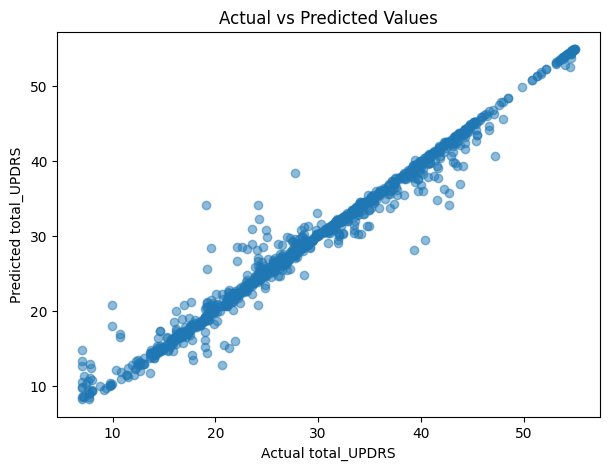

In [52]:
plt.figure(figsize=(7, 5))
plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)
plt.xlabel(
    "Actual total_UPDRS"
)
plt.ylabel(
    "Predicted total_UPDRS"
)
plt.title(
    "Actual vs Predicted Values"
)
plt.show()

### Observation

The Actual vs Predicted plot helps visually compare model predictions with the real target values.

Points closer to the ideal diagonal relationship indicate better predictions.

In [53]:
residuals = y_test - rf_pred

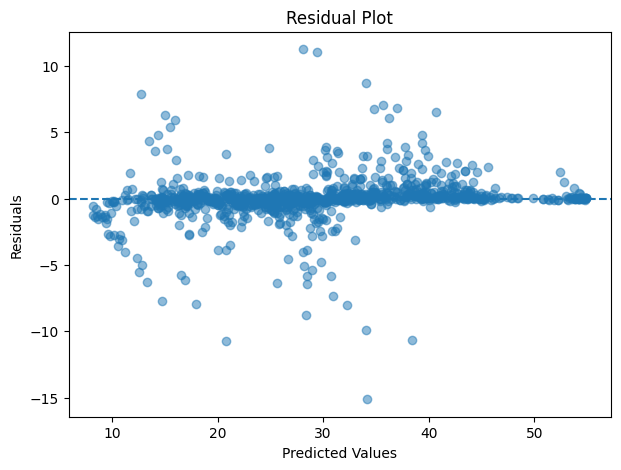

In [54]:
plt.figure(figsize=(7, 5))
plt.scatter(
    rf_pred,
    residuals,
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel(
    "Predicted Values"
)
plt.ylabel(
    "Residuals"
)
plt.title(
    "Residual Plot"
)
plt.show()

### Observation

The residual plot is used to check whether prediction errors are randomly distributed around zero.

If there is no strong pattern in the residuals, the regression model is generally behaving appropriately.

# Feature Importance

Random Forest can estimate the relative importance of each input feature.

Feature importance helps identify which measurements contribute more strongly to the prediction of 'total_UPDRS'.

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [56]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
0,age,0.638772
17,DFA,0.088013
1,sex,0.088001
2,test_time,0.066863
15,HNR,0.032339
16,RPDE,0.027031
4,Jitter(Abs),0.014707
14,NHR,0.007060
19,Shimmer_Jitter_Ratio,0.005413
18,PPE,0.004567


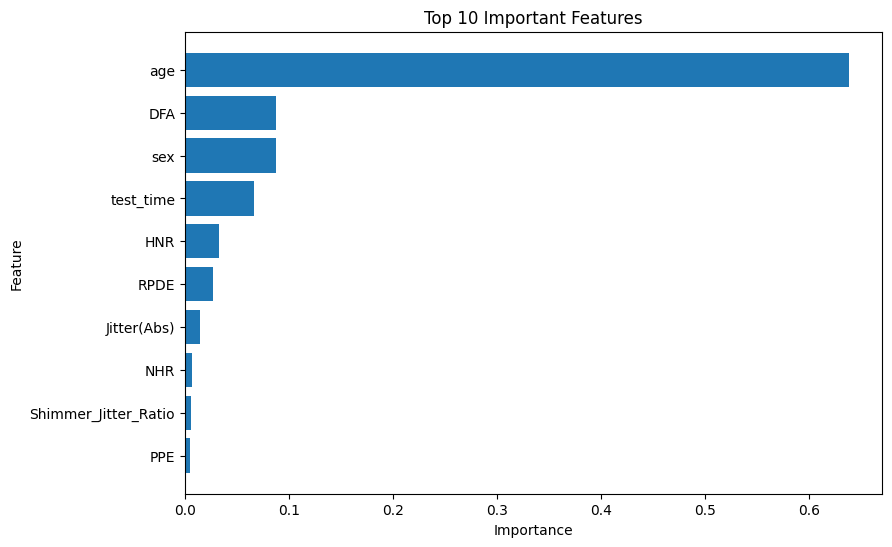

In [57]:
top_features = feature_importance.head(10)
plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 10 Important Features"
)
plt.gca().invert_yaxis()
plt.show()